# Confronto migliori modelli SVM e Random Forest

[ISTRUZIONI PAIR T-TEST CONFRONTARE DUE MODELLI](https://scikit-learn.org/stable/auto_examples/model_selection/plot_grid_search_stats.html)

In [2]:
import pandas as pd

# DataFrame risultati Random Forest
results_rf = pd.read_pickle("results/prime-prove/results_rf_GridSearch.pkl")

# DataFrame risultati SVM
results_svm = pd.read_pickle("results/results-svm-savgol-fine-GridSearch.pkl")

# DataFrame risultati singolo neurone Neural Network
results_nn = pd.read_pickle("results/results-nn-savgol-fine-GridSearch.pkl")

# DataFrame risultati 3 neuroni due layer Neural Network
results_two_nn = pd.read_pickle("results/results-nn-two-layer-savgol-GridSearch.pkl")

Per Random Forest si considera come miglior modello quello restituito da GridSearchCV.best_estimator_, mentre per SVM si preferisce prendere un modello con accuracy simile al 'migliore' ma con sensitivity molto più alta.

In [ ]:
# Indici dei modelli scelti
best_idx_svm = results_svm['rank_test_score'].idxmin() # miglior accuracy
best_idx_rf = results_rf['rank_test_score'].idxmin() # miglior accuracy
best_idx_nn = results_nn['rank_test_score'].idxmin() # miglior accuracy

In [ ]:
results_two_nn

Questi i valori di accuracy e sensitivity:

In [ ]:
print("RANDOM FOREST:") 
print(f"- Accuracy: {results_rf['mean_test_score'][best_idx_rf]:.4f} ± {results_rf['std_test_score'][best_idx_rf]:.4f}" )
print(f"- Sensitivity: {results_rf['mean_test_sensitivity'][best_idx_rf]:.4f} ± {results_rf['std_test_sensitivity'][best_idx_rf]:.4f}" )

print("SVM:") 
print(f"- Accuracy: {results_svm['mean_test_score'][best_idx_svm]:.4f} ± {results_svm['std_test_score'][best_idx_svm]:.4f}" )
print(f"- Sensitivity: {results_svm['mean_test_sensitivity'][best_idx_svm]:.4f} ± {results_svm['std_test_sensitivity'][best_idx_svm]:.4f}" )

print("NEURON:") 
print(f"- Accuracy: {results_nn['mean_test_score'][best_idx_nn]:.4f} ± {results_nn['std_test_score'][best_idx_nn]:.4f}" )
print(f"- Sensitivity: {results_nn['mean_test_sensitivity'][best_idx_nn]:.4f} ± {results_nn['std_test_sensitivity'][best_idx_nn]:.4f}" )

RANDOM FOREST:
- Accuracy: 0.8854 ± 0.1307
- Sensitivity: 0.9417 ± 0.1267
SVM:
- Accuracy: 0.9812 ± 0.0446
- Sensitivity: 0.9667 ± 0.0850
NEURON:
- Accuracy: 0.9458 ± 0.0660
- Sensitivity: 0.9958 ± 0.0320


Ad occhio, accuracy non è significativamente diversa, mentre sensitivity sì.

---

## Comparazione SVM & RANDOM FOREST con approccio frequentista

### ❓ **Domanda**: Random Forest è significativamente migliore di SVM, comparati su accuracy e sensitivity?

La risposta _frequentista_ prevede di fare un t-test a coppie e calcolare il p-value. In letteratura, è noto come 'test Diebold-Mariano'. La variante proposta nel tutorial di scikit-learn è specificatamente pensata per confrontare modelli su partizioni casuali dello stesso dataset, come nel nostro caso con `RepeatedStratifiedKFold`, chiamato **test t corretto di Nadeau e Bengio**.

$$
t = 
\frac{\frac{1}{k\cdot r}\sum_{i=1}^{r}\sum_{j=1}^{k} x_{ij}}
{
    \sqrt{ \left(\frac{1}{k\cdot r} + \frac{n_\text{test}}{n_\text{train}}\right) \hat{\sigma}^2 }
}
$$

Dove: 
- $k$ è il numero di fold (6),
- $r$ è il numero di ripetizioni della cross-validation (10),
- $x_{ij}$ è la differenza nella performance tra i due modelli, 
- $n_\text{test}$ è il numero di sample usati per il testing, 
- $n_\text{test}$ è il numero di sample usati per il training,  
- $\hat\sigma$ è la varianza delle differenze osservate (assunte distrubite normalmente).



**test t corretto di Nadeau e Bengio**

In [ ]:
import numpy as np
from scipy.stats import t

def corrected_std(differences, n_train, n_test):
    """Corrects standard deviation using Nadeau and Bengio's approach.

    Parameters
    ----------
    differences : ndarray of shape (n_samples,)
        Vector containing the differences in the score metrics of two models.
    n_train : int
        Number of samples in the training set.
    n_test : int
        Number of samples in the testing set.

    Returns
    -------
    corrected_std : float
        Variance-corrected standard deviation of the set of differences.
    """
    # kr = k times r, r times repeated k-fold crossvalidation,
    # kr equals the number of times the model was evaluated
    kr = len(differences)
    corrected_var = np.var(differences, ddof=1) * (1 / kr + n_test / n_train)
    corrected_std = np.sqrt(corrected_var)
    return corrected_std


def compute_corrected_ttest(differences, df, n_train, n_test):
    """Computes right-tailed paired t-test with corrected variance.

    Parameters
    ----------
    differences : array-like of shape (n_samples,)
        Vector containing the differences in the score metrics of two models.
    df : int
        Degrees of freedom.
    n_train : int
        Number of samples in the training set.
    n_test : int
        Number of samples in the testing set.

    Returns
    -------
    t_stat : float
        Variance-corrected t-statistic.
    p_val : float
        Variance-corrected p-value.
    """
    mean = np.mean(differences)
    std = corrected_std(differences, n_train, n_test)
    t_stat = mean / std
    p_val = t.sf(np.abs(t_stat), df)  # right-tailed t-test
    return t_stat, p_val

#### confronto **accuracy** 

In [ ]:
# --- PARAMETRI DEL DATASET E DELLA GRID SEARCH ---
n_total = 48
n_splits = 6
n_repeats = 10
n_test = n_total / n_splits
n_train = n_total - n_test
dof = (n_splits * n_repeats) - 1 

# --- 1. ESTRAZIONE SCORE ---

# Colonne dei singoli split (ne abbiamo 60: 6 fold * 10 ripetizioni)
split_cols = [f'split{i}_test_score' for i in range(n_splits * n_repeats)]

# Estraiamo i vettori di accuracy
scores_svm = results_svm.loc[best_idx_svm, split_cols].values.astype(float)
scores_rf = results_rf.loc[best_idx_rf, split_cols].values.astype(float)

# --- 2. CALCOLO DIFFERENZE ---
differences = scores_rf - scores_svm

# --- 3. TEST STATISTICO (Funzioni Tutorial) ---
t_stat, p_val_one_tailed = compute_corrected_ttest(differences, dof, n_train, n_test)


# --- 4. OUTPUT ---
print(f"Modello SVM (Migliore Sensitivity): Accuracy Media = {scores_svm.mean():.4f}")
print(f"Modello RF  (Migliore): Accuracy Media = {scores_rf.mean():.4f}")
print("-" * 40)
print(f"T-statistic corretta: {t_stat:.4f}")
print(f"P-value (ONE-tailed): {p_val_one_tailed:.5f}")

Modello SVM (Migliore Sensitivity): Accuracy Media = 0.9812
Modello RF  (Migliore): Accuracy Media = 0.8806
----------------------------------------
T-statistic corretta: -1.5635
P-value (ONE-tailed): 0.06164


#### confronto **sensitivity**

In [ ]:
# --- 1. ESTRAZIONE SCORE DI SENSITIVITY ---
# Nota: GridSearch usa solitamente 'split0_test_sensitivity' 
# (o il nome che hai dato alla metrica nel dizionario scoring)
split_cols_sens = [f'split{i}_test_sensitivity' for i in range(80)]

scores_svm_sens = results_svm.loc[best_idx_svm, split_cols_sens].values.astype(float)
scores_rf_sens = results_rf.loc[best_idx_rf, split_cols_sens].values.astype(float)

# --- 2. CALCOLO DIFFERENZE ---
diff_sens = scores_rf_sens - scores_svm_sens

# --- 3. TEST STATISTICO (Stesse funzioni di prima) ---
t_stat_sens, p_val_sens = compute_corrected_ttest(diff_sens, dof, n_train, n_test)

print(f"SVM Sensitivity Media: {scores_svm_sens.mean():.4f}")
print(f"RF  Sensitivity Media: {scores_rf_sens.mean():.4f}")
print("-" * 40)
print(f"T-statistic corretta: {t_stat_sens:.4f}")
print(f"P-value Sensitivity (ONE-tailed): {p_val_sens:.4f}")

KeyError: "['split60_test_sensitivity', 'split61_test_sensitivity', 'split62_test_sensitivity', 'split63_test_sensitivity', 'split64_test_sensitivity', 'split65_test_sensitivity', 'split66_test_sensitivity', 'split67_test_sensitivity', 'split68_test_sensitivity', 'split69_test_sensitivity', 'split70_test_sensitivity', 'split71_test_sensitivity', 'split72_test_sensitivity', 'split73_test_sensitivity', 'split74_test_sensitivity', 'split75_test_sensitivity', 'split76_test_sensitivity', 'split77_test_sensitivity', 'split78_test_sensitivity', 'split79_test_sensitivity'] not in index"

<blank>

---

## Comparazione SVM & NEURAL NETWORK con approccio frequentista

#### confronto **accuracy** 

In [ ]:
# --- PARAMETRI DEL DATASET E DELLA GRID SEARCH ---
n_total = 48
n_splits = 6
n_repeats = 10
n_test = n_total / n_splits
n_train = n_total - n_test
dof = (n_splits * n_repeats) - 1 

# --- 1. ESTRAZIONE SCORE ---

# Colonne dei singoli split (ne abbiamo 60: 6 fold * 10 ripetizioni)
split_cols = [f'split{i}_test_score' for i in range(n_splits * n_repeats)]

# Estraiamo i vettori di accuracy
scores_svm = results_svm.loc[best_idx_svm, split_cols].values.astype(float)
scores_nn = results_nn.loc[best_idx_nn, split_cols].values.astype(float)

# --- 2. CALCOLO DIFFERENZE ---
differences = scores_nn - scores_svm

# --- 3. TEST STATISTICO (Funzioni Tutorial) ---
t_stat, p_val_one_tailed = compute_corrected_ttest(differences, dof, n_train, n_test)


# --- 4. OUTPUT ---
print(f"Modello SVM (Migliore Sensitivity): Accuracy Media = {scores_svm.mean():.4f}")
print(f"Modello NN  (Migliore): Accuracy Media = {scores_nn.mean():.4f}")
print("-" * 40)
print(f"T-statistic corretta: {t_stat:.4f}")
print(f"P-value (ONE-tailed): {p_val_one_tailed:.5f}")

Modello SVM (Migliore Sensitivity): Accuracy Media = 0.9812
Modello NN  (Migliore): Accuracy Media = 0.9458
----------------------------------------
T-statistic corretta: -0.9137
P-value (ONE-tailed): 0.18229


#### confronto **sensitivity**

In [ ]:
# --- 1. ESTRAZIONE SCORE DI SENSITIVITY ---
# Nota: GridSearch usa solitamente 'split0_test_sensitivity' 
# (o il nome che hai dato alla metrica nel dizionario scoring)
split_cols_sens = [f'split{i}_test_sensitivity' for i in range(n_splits * n_repeats)]

scores_svm_sens = results_svm.loc[best_idx_svm, split_cols_sens].values.astype(float)
scores_nn_sens = results_nn.loc[best_idx_nn, split_cols_sens].values.astype(float)

# --- 2. CALCOLO DIFFERENZE ---
diff_sens = scores_nn_sens - scores_svm_sens

# --- 3. TEST STATISTICO (Stesse funzioni di prima) ---
t_stat_sens, p_val_sens = compute_corrected_ttest(diff_sens, dof, n_train, n_test)

print(f"SVM Sensitivity Media: {scores_svm_sens.mean():.4f}")
print(f"NN  Sensitivity Media: {scores_nn_sens.mean():.4f}")
print("-" * 40)
print(f"T-statistic corretta: {t_stat_sens:.4f}")
print(f"P-value Sensitivity (ONE-tailed): {p_val_sens:.4f}")

SVM Sensitivity Media: 0.9667
NN  Sensitivity Media: 0.9958
----------------------------------------
T-statistic corretta: 0.7742
P-value Sensitivity (ONE-tailed): 0.2209


---

Il test assume che le differenze siano distrubuite normalmente. Vediamo al volo se è così:

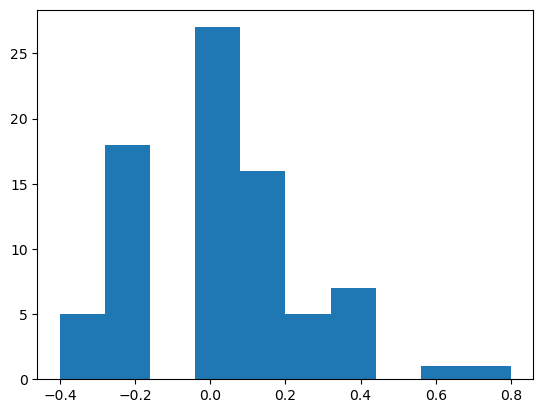

In [ ]:
import matplotlib.pyplot as plt
plt.hist(differences)
plt.show()